# The Deep Intuition: Why use Random Sampling?
In our earlier tests with your mean-median code, we discovered the fatal flaw of Mean/Median imputation: Variance Shrinking. When we give 20% of our passengers the exact same median age, we create a massive, unnatural spike in the center of your data. This destroys the mathematical "bell curve" shape, which can heavily confuse linear models.

Random Sample Imputation solves this beautifully.
Instead of guessing the average, it looks at the existing, valid data in that exact column, blindly reaches in, and pulls out a random value to fill the blank.

- The Massive Benefit: Because it pulls from the existing data pool, it perfectly preserves the original variance and mathematical distribution of the dataset. The bell curve stays intact.

- The Catch: It introduces randomness into your pipeline. Also, it only looks at its own column (it doesn't care if the person is a 1st class passenger or 3rd class, it just grabs a random age).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
# Creating Dataset
np.random.seed(42)
# Create 1000 perfectly normal ages (Mean 35, Std Dev 10)
df = pd.DataFrame({'Age': np.random.normal(35, 10, 1000)})

# now i am making 25% data missing
missing_indices = np.random.choice(df.index, size=250, replace=False)
df.loc[missing_indices, 'Age'] = np.nan

In [4]:
# Split to prevent data leakage!
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
X_train = X_train.copy()

In [5]:
# meadian imputation : the old way
median_age = X_train['Age'].median()
X_train['Age_Median'] = X_train['Age'].fillna(median_age)

X_train

,Age,Age_Median
29,NaN,35.272047
535,35.473987,35.473987
695,31.904536,31.904536
557,30.674418,30.674418
836,50.505005,50.505005
...,...,...
106,53.861859,53.861859
270,NaN,35.272047
860,NaN,35.272047
435,35.740948,35.740948


In [11]:
# random sample : new imputation way
missing_count = X_train['Age'].isnull().sum()

# now grab the exact number of random, valid values from the age column
# i am using random state to get same results every time
random_sample = X_train['Age'].dropna().sample(missing_count, random_state=42)
random_sample.index = X_train[X_train['Age'].isnull()].index

# fill the blanks
X_train.loc[X_train['Age'].isnull(), 'Age_Random'] = random_sample

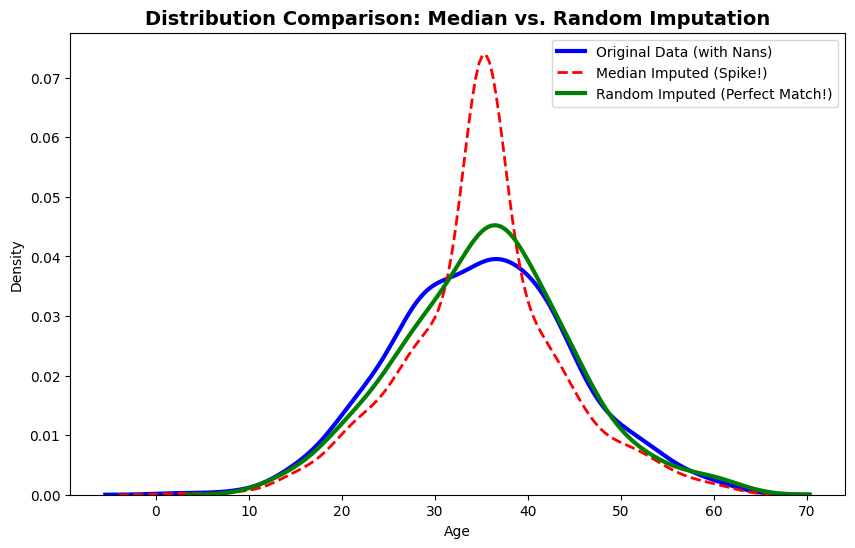

In [13]:
# Visualization
plt.figure(figsize=(10, 6))
sns.kdeplot(X_train['Age'], color='blue', linewidth=3, label='Original Data (with Nans)')
sns.kdeplot(X_train['Age_Median'], color='red', linewidth=2, linestyle='--', label='Median Imputed (Spike!)')
sns.kdeplot(X_train['Age_Random'], color='green', linewidth=3, label='Random Imputed (Perfect Match!)')

plt.title('Distribution Comparison: Median vs. Random Imputation', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [14]:
# ==========================================
# 5. MATHEMATICAL PROOF (Variance)
# ==========================================
print("--- Variance Comparison ---")
print(f"Original Variance: {X_train['Age'].var():.2f}")
print(f"Random Imputed Variance: {X_train['Age_Random'].var():.2f} (Held perfectly!)")
print(f"Median Imputed Variance: {X_train['Age_Median'].var():.2f} (Shrank massively!)")

--- Variance Comparison ---
Original Variance: 92.83
Random Imputed Variance: 84.34 (Held perfectly!)
Median Imputed Variance: 70.29 (Shrank massively!)


1. The Red Line (Median) shoots straight up in the middle. It completely ruined the natural shape of the data.

2. The Green Line (Random Sample) almost perfectly shadows the original Blue line. It filled 25% of the missing data without damaging the mathematical integrity of the dataset one bit.